# 01 — Build static regional predictors

Rebuild elevation and soil-composition tables from `data/raw/`, writing to `data/processed/`.
Land cover and population rasters live under `data/static/` and are zonally aggregated in notebook `02`.


In [1]:
from __future__ import annotations

import time
import warnings
import xml.etree.ElementTree as ET
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from IPython.display import display
from matplotlib.patches import Patch
from rasterio.features import rasterize
from rasterio.mask import mask as rio_mask
from rasterio.windows import Window, from_bounds, transform as window_transform
from shapely import make_valid
from shapely.geometry import MultiPolygon, Polygon, mapping

warnings.filterwarnings("ignore")

PACKAGE_ROOT = Path("..").resolve()
if not (PACKAGE_ROOT / "data").exists():
    PACKAGE_ROOT = Path(".").resolve()
    if PACKAGE_ROOT.name == "notebooks":
        PACKAGE_ROOT = PACKAGE_ROOT.parent

RAW_DIR = PACKAGE_ROOT / "data" / "raw"
STATIC_DIR = PACKAGE_ROOT / "data" / "static"
OUT_DIR = PACKAGE_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEM_TIF = RAW_DIR / "elevation" / "10_DEM_y50x0.tif"
SOIL_GML = next((RAW_DIR / "soil").glob("**/BRO-SGM-Bodemkaart-V2025-01.gml"), None)
if SOIL_GML is None:
    SOIL_GML = next(RAW_DIR.glob("**/BRO-SGM-Bodemkaart-V2025-01.gml"), None)
GPKG_CACHE = OUT_DIR / "bro_soilmap_v2025_01.gpkg"
NUTS_GEOJSON = PACKAGE_ROOT / "data" / "input" / "nuts_nl_simplified.geojson"
CLC_TIF = STATIC_DIR / "land" / "U2018_CLC2018_V2020_20u1.tif"
POP_TIF = STATIC_DIR / "population" / "nld_pop_2018_CN_100m_R2025A_v1.tif"
BRO_GML = SOIL_GML  # alias used by soil EDA cells
SOIL_FIG_DIR = OUT_DIR / "soil_eda"
SOIL_FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / "images_for_elevation_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)
# Curated hand-in figures (1 elev + 3 soil)
STATIC_FIG_DIR = PACKAGE_ROOT / "results" / "figures" / "statics"
STATIC_FIG_DIR.mkdir(parents=True, exist_ok=True)

NL_BOUNDS = (3.2, 50.7, 7.3, 53.7)  # left, bottom, right, top
NL_BUFFER_DEG = 0.15
FIG_DPI = 150

print(f"Package: {PACKAGE_ROOT}")
print(f"DEM:  {DEM_TIF} exists={DEM_TIF.exists()}")
print(f"Soil: {SOIL_GML} exists={SOIL_GML is not None and SOIL_GML.exists()}")
print(f"Out:  {OUT_DIR}")


Package: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting
DEM:  C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\raw\elevation\10_DEM_y50x0.tif exists=True
Soil: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\raw\soil\BRO-SGM-Bodemkaart-V2025-01.gml exists=True
Out:  C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed


## Elevation (DEM → NUTS-3 mean/min/max/std)


## 0. Config and paths

## 1. DEM metadata EDA

In [2]:
with rasterio.open(DEM_TIF) as src:
    dem_meta = {
        "crs": str(src.crs),
        "width": src.width,
        "height": src.height,
        "count": src.count,
        "dtype": src.dtypes[0],
        "nodata": src.nodata,
        "res_x": src.res[0],
        "res_y": src.res[1],
        "left": src.bounds.left,
        "bottom": src.bounds.bottom,
        "right": src.bounds.right,
        "top": src.bounds.top,
        "file_mb": DEM_TIF.stat().st_size / 1e6,
        "tags": dict(src.tags()),
    }

print("DEM metadata")
for k, v in dem_meta.items():
    if k != "tags":
        print(f"  {k}: {v}")
print(f"  tags: {dem_meta['tags']}")
print()
print("Note: nodata is None — ocean pixels have low/negative elevations, not masked.")
print("Below-sea-level land inside NL polygons (polders) is kept on purpose.")


DEM metadata
  crs: EPSG:4326
  width: 8001
  height: 12001
  count: 1
  dtype: float32
  nodata: None
  res_x: 0.00125
  res_y: 0.0008333333333333334
  left: -0.000625
  bottom: 49.999583333333334
  right: 10.000625000000001
  top: 60.000416666666666
  file_mb: 130.796811
  tags: {'AREA_OR_POINT': 'Area'}

Note: nodata is None — ocean pixels have low/negative elevations, not masked.
Below-sea-level land inside NL polygons (polders) is kept on purpose.


In [3]:
left, bottom, right, top = NL_BOUNDS
nl_window_bounds = (
    left - NL_BUFFER_DEG,
    bottom - NL_BUFFER_DEG,
    right + NL_BUFFER_DEG,
    top + NL_BUFFER_DEG,
)

with rasterio.open(DEM_TIF) as src:
    win = from_bounds(*nl_window_bounds, transform=src.transform)
    win = win.round_offsets().round_lengths()
    # Clip window to raster extent
    win = Window(
        max(0, int(win.col_off)),
        max(0, int(win.row_off)),
        min(int(win.width), src.width - max(0, int(win.col_off))),
        min(int(win.height), src.height - max(0, int(win.row_off))),
    )
    dem_nl = src.read(1, window=win).astype(np.float32)
    dem_nl_transform = window_transform(win, src.transform)
    dem_crs = src.crs

print(f"NL window shape: {dem_nl.shape}")
print(f"NL window elev — min/max/mean: {dem_nl.min():.2f} / {dem_nl.max():.2f} / {dem_nl.mean():.2f} m")
print(f"Share < 0 m: {(dem_nl < 0).mean() * 100:.2f}%")
print(f"Share < -5 m (likely sea in this window): {(dem_nl < -5).mean() * 100:.2f}%")


NL window shape: (3960, 3520)
NL window elev — min/max/mean: -292.64 / 674.42 / 27.85 m
Share < 0 m: 9.42%
Share < -5 m (likely sea in this window): 0.29%


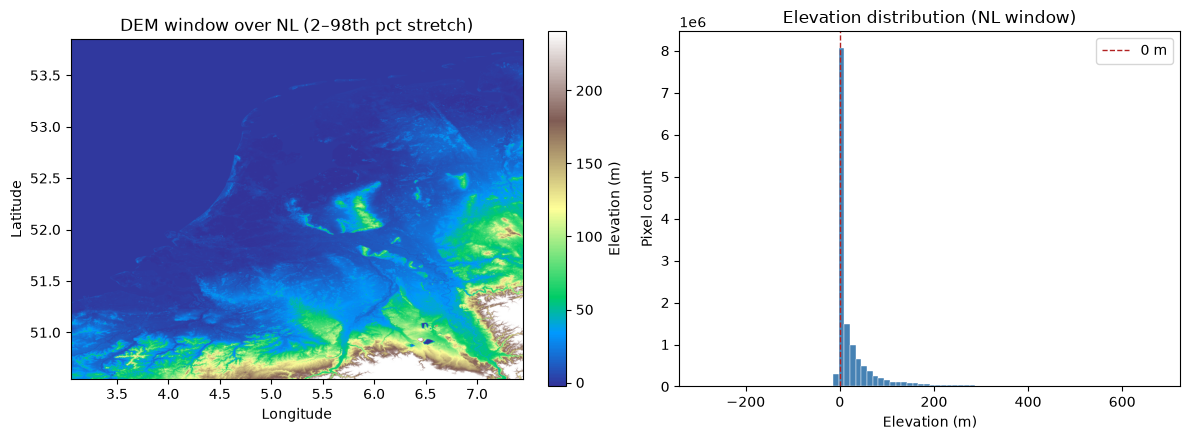

Saved: fig_dem_nl_map_hist.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
vmin, vmax = np.percentile(dem_nl, [2, 98])
im = ax.imshow(
    dem_nl,
    cmap="terrain",
    vmin=vmin,
    vmax=vmax,
    extent=[
        dem_nl_transform.c,
        dem_nl_transform.c + dem_nl_transform.a * dem_nl.shape[1],
        dem_nl_transform.f + dem_nl_transform.e * dem_nl.shape[0],
        dem_nl_transform.f,
    ],
    origin="upper",
)
ax.set_title("DEM window over NL (2–98th pct stretch)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(im, ax=ax, fraction=0.046, label="Elevation (m)")

ax = axes[1]
ax.hist(dem_nl.ravel(), bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_title("Elevation distribution (NL window)")
ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Pixel count")
ax.axvline(0, color="firebrick", ls="--", lw=1, label="0 m")
ax.legend()

fig.tight_layout()
fig_path = FIG_DIR / "fig_dem_nl_map_hist.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


## 2. Coverage check — NUTS-3 vs DEM extent

In [5]:
gdf = gpd.read_file(NUTS_GEOJSON)
nuts3 = gdf[gdf["LEVL_CODE"] == 3][["NUTS_ID", "NAME_LATN", "geometry"]].copy()
nuts3 = nuts3.rename(columns={"NUTS_ID": "nuts3_id", "NAME_LATN": "nuts3_name"})
nuts3 = nuts3.reset_index(drop=True)

print(f"NUTS3 regions: {len(nuts3)}")
print(f"NUTS CRS: {nuts3.crs}")
assert len(nuts3) == 40

nuts_bounds = nuts3.total_bounds  # minx, miny, maxx, maxy
dem_left, dem_bottom = dem_meta["left"], dem_meta["bottom"]
dem_right, dem_top = dem_meta["right"], dem_meta["top"]

covered = (
    nuts_bounds[0] >= dem_left
    and nuts_bounds[1] >= dem_bottom
    and nuts_bounds[2] <= dem_right
    and nuts_bounds[3] <= dem_top
)
print(f"NUTS3 total bounds: {nuts_bounds}")
print(f"DEM bounds:         ({dem_left}, {dem_bottom}, {dem_right}, {dem_top})")
print(f"All NUTS3 inside DEM extent: {covered}")
if not covered:
    raise ValueError("NUTS3 extent is not fully covered by the DEM — check tile coverage.")


NUTS3 regions: 40
NUTS CRS: EPSG:4326
NUTS3 total bounds: [ 3.3593588  50.75096449  7.22586148 53.55438204]
DEM bounds:         (-0.000625, 49.999583333333334, 10.000625000000001, 60.000416666666666)
All NUTS3 inside DEM extent: True


## 3. Aggregate DEM → NUTS-3 (windowed rasterize)

In [6]:
# Same pattern as WorldPop in Data_preparation_prediction.ipynb:
# rasterize NUTS polygons onto the DEM grid, then per-region stats.
nuts3_dem = nuts3.to_crs(dem_crs) if dem_crs else nuts3
region_ids = nuts3_dem["nuts3_id"].tolist()
id_to_label = {rid: i + 1 for i, rid in enumerate(region_ids)}

nuts3_raster = rasterize(
    [(geom, id_to_label[rid]) for rid, geom in zip(region_ids, nuts3_dem.geometry)],
    out_shape=dem_nl.shape,
    transform=dem_nl_transform,
    fill=0,
    dtype=np.uint16,
    all_touched=False,
)

elev_records = []
for rid in region_ids:
    label = id_to_label[rid]
    region_mask = nuts3_raster == label
    n_pix = int(region_mask.sum())
    if n_pix == 0:
        elev_records.append(
            {
                "nuts3_id": rid,
                "elevation_mean": np.nan,
                "elevation_min": np.nan,
                "elevation_max": np.nan,
                "elevation_std": np.nan,
                "n_valid_pixels": 0,
            }
        )
        continue
    vals = dem_nl[region_mask]
    elev_records.append(
        {
            "nuts3_id": rid,
            "elevation_mean": float(np.nanmean(vals)),
            "elevation_min": float(np.nanmin(vals)),
            "elevation_max": float(np.nanmax(vals)),
            "elevation_std": float(np.nanstd(vals)),
            "n_valid_pixels": n_pix,
        }
    )

static_elev = pd.DataFrame(elev_records).merge(
    nuts3[["nuts3_id", "nuts3_name"]], on="nuts3_id", how="left"
)

missing = static_elev.loc[static_elev["n_valid_pixels"] == 0, "nuts3_id"].tolist()
if missing:
    print("WARNING: regions with zero valid elevation pixels:", missing)
else:
    print("All 40 NUTS3 regions have elevation coverage.")

print(f"Pixels assigned to any NUTS3: {(nuts3_raster > 0).sum():,}")
display(static_elev.sort_values("elevation_mean").head(5))
display(static_elev.sort_values("elevation_mean", ascending=False).head(5))


All 40 NUTS3 regions have elevation coverage.
Pixels assigned to any NUTS3: 4,721,599


,nuts3_id,elevation_mean,elevation_min,elevation_max,elevation_std,n_valid_pixels,nuts3_name
33,NL33B,-2.137121,-8.290668,15.453964,2.005654,65437,Oost-Zuid-Holland
14,NL230,-1.632435,-11.598929,27.205816,2.886598,306556,Flevoland
28,NL329,-1.419552,-10.690617,30.368933,2.982529,110754,Groot-Amsterdam
9,NL325,-1.087106,-5.500000,21.828455,2.466864,16226,Zaanstreek
15,NL321,-0.727537,-7.929406,25.018656,2.393986,193573,Kop van Noord-Holland


,nuts3_id,elevation_mean,elevation_min,elevation_max,elevation_std,n_valid_pixels,nuts3_name
0,NL423,107.336945,19.931786,325.033081,48.928562,81106,Zuid-Limburg
5,NL422,31.619318,13.500000,99.220482,9.525426,85555,Midden-Limburg
1,NL414,26.183754,4.350454,60.611141,7.599866,180926,Zuidoost-Noord-Brabant
4,NL421,25.796268,7.000000,90.421684,8.558173,105938,Noord-Limburg
26,NL221,24.866829,-1.557855,124.155632,22.507954,234961,Veluwe


## 4. QA — summaries and choropleth

In [7]:
qa_cols = [
    "elevation_mean",
    "elevation_min",
    "elevation_max",
    "elevation_std",
    "n_valid_pixels",
]
print("Summary stats (NUTS3 elevation)")
display(static_elev[qa_cols].describe().round(3))

print("Lowest mean elevation")
display(
    static_elev.nsmallest(5, "elevation_mean")[
        ["nuts3_id", "nuts3_name", "elevation_mean", "elevation_min", "elevation_max"]
    ].round(2)
)
print("Highest mean elevation")
display(
    static_elev.nlargest(5, "elevation_mean")[
        ["nuts3_id", "nuts3_name", "elevation_mean", "elevation_min", "elevation_max"]
    ].round(2)
)


Summary stats (NUTS3 elevation)


,elevation_mean,elevation_min,elevation_max,elevation_std,n_valid_pixels
count,40.000,40.000,40.000,40.000,40.000
mean,9.649,-3.778,57.268,7.304,118039.975
std,18.319,6.746,51.399,8.301,70153.580
min,-2.137,-15.560,15.454,1.681,16226.000
25%,0.543,-6.895,30.214,2.499,61654.500
50%,3.819,-4.796,41.617,5.909,113521.500
75%,11.565,-1.984,58.004,7.741,178643.000
max,107.337,19.932,325.033,48.929,306556.000


Lowest mean elevation


,nuts3_id,nuts3_name,elevation_mean,elevation_min,elevation_max
33,NL33B,Oost-Zuid-Holland,-2.14,-8.29,15.45
14,NL230,Flevoland,-1.63,-11.60,27.21
28,NL329,Groot-Amsterdam,-1.42,-10.69,30.37
9,NL325,Zaanstreek,-1.09,-5.50,21.83
15,NL321,Kop van Noord-Holland,-0.73,-7.93,25.02


Highest mean elevation


,nuts3_id,nuts3_name,elevation_mean,elevation_min,elevation_max
0,NL423,Zuid-Limburg,107.34,19.93,325.03
5,NL422,Midden-Limburg,31.62,13.50,99.22
1,NL414,Zuidoost-Noord-Brabant,26.18,4.35,60.61
4,NL421,Noord-Limburg,25.80,7.00,90.42
26,NL221,Veluwe,24.87,-1.56,124.16


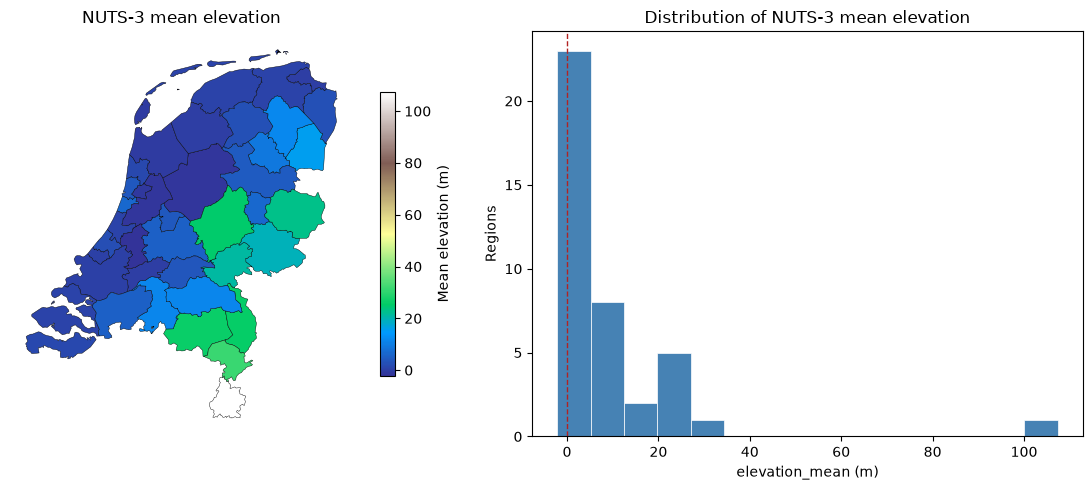

Saved: fig_elevation_nuts3_choropleth.png


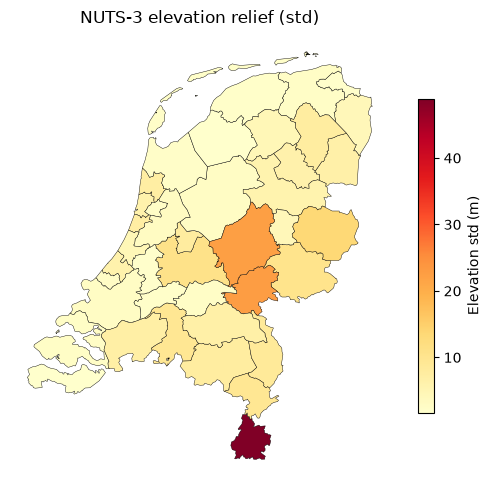

Saved: fig_elevation_nuts3_std.png


In [8]:
plot_gdf = nuts3.merge(static_elev.drop(columns=["nuts3_name"]), on="nuts3_id", how="left")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
plot_gdf.plot(
    column="elevation_mean",
    ax=ax,
    cmap="terrain",
    legend=True,
    legend_kwds={"label": "Mean elevation (m)", "shrink": 0.7},
    edgecolor="k",
    linewidth=0.3,
)
ax.set_title("NUTS-3 mean elevation")
ax.set_axis_off()

ax = axes[1]
ax.hist(
    static_elev["elevation_mean"].dropna(),
    bins=15,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
)
ax.set_title("Distribution of NUTS-3 mean elevation")
ax.set_xlabel("elevation_mean (m)")
ax.set_ylabel("Regions")
ax.axvline(0, color="firebrick", ls="--", lw=1)

fig.tight_layout()
fig_path = FIG_DIR / "fig_elevation_nuts3_choropleth.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")

# Extra: relief (std) choropleth
fig, ax = plt.subplots(figsize=(6, 5))
plot_gdf.plot(
    column="elevation_std",
    ax=ax,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Elevation std (m)", "shrink": 0.7},
    edgecolor="k",
    linewidth=0.3,
)
ax.set_title("NUTS-3 elevation relief (std)")
ax.set_axis_off()
fig.tight_layout()
fig_path = FIG_DIR / "fig_elevation_nuts3_std.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


## 5. Export static elevation table

In [9]:
export_cols = [
    "nuts3_id",
    "nuts3_name",
    "elevation_mean",
    "elevation_min",
    "elevation_max",
    "elevation_std",
    "n_valid_pixels",
]

elev_parquet = OUT_DIR / "static_elevation_nuts3.parquet"
elev_csv = OUT_DIR / "static_elevation_nuts3.csv"
static_elev[export_cols].to_parquet(elev_parquet, index=False)
static_elev[export_cols].to_csv(elev_csv, index=False)

print(f"Saved: {elev_parquet.name}")
print(f"Saved: {elev_csv.name}")
print(f"Rows: {len(static_elev)}  |  NaN in elevation_mean: {static_elev['elevation_mean'].isna().sum()}")
display(static_elev[export_cols].sort_values("nuts3_id").reset_index(drop=True))


Saved: static_elevation_nuts3.parquet
Saved: static_elevation_nuts3.csv
Rows: 40  |  NaN in elevation_mean: 0


,nuts3_id,nuts3_name,elevation_mean,elevation_min,elevation_max,elevation_std,n_valid_pixels
0,NL111,Oost-Groningen,2.912997,-8.970581,35.838650,4.280666,109698
1,NL112,Delfzijl en omgeving,-0.041565,-4.047389,25.341526,2.020347,35413
2,NL113,Overig Groningen,0.693393,-4.636781,28.793802,2.445153,165292
3,NL124,Noord-Friesland,0.581852,-5.531028,42.292255,2.102778,207184
4,NL125,Zuidwest-Friesland,-0.290547,-6.000000,31.959040,1.683653,177882
5,NL126,Zuidoost-Friesland,2.874165,-4.730749,38.246155,4.543854,129557
6,NL131,Noord-Drenthe,11.974593,-2.500000,52.899128,7.719456,136116
7,NL132,Zuidoost-Drenthe,15.759478,3.170771,49.439251,6.619382,117774
8,NL133,Zuidwest-Drenthe,9.099692,-2.000000,41.116440,6.227032,88981
9,NL211,Noord-Overijssel,4.372690,-4.522746,73.814896,5.859533,190004


## 6. Next step — wire into prediction panel

When ready to use elevation in the model:

1. In `Data_preparation_prediction.ipynb`, load `static_elevation_nuts3.parquet`.
2. Merge on `nuts3_id` (m:1, same as land cover / population).
3. Add **`elevation_mean`** to `STATIC_FEATURES` (and optionally `elevation_std` for relief).
4. Rebuild the supervised panel / feature manifest.

This notebook does **not** modify the prediction prep pipeline.

## Soil composition (BRO map → NUTS-3 main-class fractions)


## 1. File format inspection

The delivery uses a `.gml` name but starts with an XML declaration and a BRO `SoilMap` root (`http://www.broservices.nl/xsd/sgm/1.1`). Do **not** open it with rasterio.

In [10]:
file_size_mb = BRO_GML.stat().st_size / 1e6
magic = BRO_GML.read_bytes()[:80].decode("utf-8", errors="replace")

print(f"File size: {file_size_mb:.2f} MB")
print(f"Magic / head: {magic!r}")
print("Format: BRO SoilMap GML/XML (vector), CRS EPSG:28992 on polygons")
print("Product: Classificatie Bodemkaart 1 : 50000 V2025-1")


def _local(tag: str) -> str:
    return tag.split("}")[-1] if "}" in tag else tag


counts = {"SoilArea": 0, "AreaOfPedologicalInterest": 0, "NormalSoilProfile": 0}
t0 = time.time()
for _event, elem in ET.iterparse(BRO_GML, events=("end",)):
    tag = _local(elem.tag)
    if tag in counts:
        counts[tag] += 1
        elem.clear()

overview = pd.DataFrame(
    [
        {"item": "file_size_mb", "value": round(file_size_mb, 2)},
        {"item": "format", "value": "BRO SoilMap GML/XML"},
        {"item": "crs", "value": "EPSG:28992"},
        {"item": "product", "value": "Classificatie Bodemkaart 1:50000 V2025-1"},
        *[{"item": f"count_{k}", "value": v} for k, v in counts.items()],
        {"item": "scan_seconds", "value": round(time.time() - t0, 1)},
    ]
)
overview.to_csv(SOIL_FIG_DIR / "soil_overview.csv", index=False)
display(overview)
print(f"Saved {SOIL_FIG_DIR / 'soil_overview.csv'}")


File size: 313.87 MB
Magic / head: '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>\n<ns23:SoilMap ns2:id="V2'
Format: BRO SoilMap GML/XML (vector), CRS EPSG:28992 on polygons
Product: Classificatie Bodemkaart 1 : 50000 V2025-1


,item,value
0,file_size_mb,313.87
1,format,BRO SoilMap GML/XML
2,crs,EPSG:28992
3,product,Classificatie Bodemkaart 1:50000 V2025-1
4,count_SoilArea,48025
5,count_AreaOfPedologicalInterest,6192
6,count_NormalSoilProfile,368
7,scan_seconds,4.0


Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_eda\soil_overview.csv


## 2. Load / cache GeoPackage

Stream-parse the GML once into a GeoPackage. Subsequent runs load the cache. Geometries are simplified (5 m) for EDA/mapping speed; `area_m2` is computed from the original polygon area before simplify.

In [11]:
def _find_child(parent, name: str):
    for child in parent:
        if _local(child.tag) == name:
            return child
    return None


def _elem_id(elem) -> str | None:
    for key, value in elem.attrib.items():
        if key == "id" or key.endswith("}id"):
            return value
    return None


def _poslists_to_geom(geom_el):
    if geom_el is None:
        return None
    polys: list[Polygon] = []
    for poly_el in geom_el.iter():
        if _local(poly_el.tag) != "Polygon":
            continue
        exterior = None
        holes: list = []
        for ring_parent in poly_el:
            rt = _local(ring_parent.tag)
            if rt not in ("exterior", "interior"):
                continue
            for pl in ring_parent.iter():
                if _local(pl.tag) != "posList" or not pl.text:
                    continue
                vals = [float(x) for x in pl.text.split()]
                coords = list(zip(vals[0::2], vals[1::2]))
                if len(coords) < 3:
                    continue
                if coords[0] != coords[-1]:
                    coords.append(coords[0])
                if rt == "exterior":
                    exterior = coords
                else:
                    holes.append(coords)
        if exterior is None:
            continue
        try:
            poly = Polygon(exterior, holes)
            if not poly.is_valid:
                poly = make_valid(poly)
            if poly.geom_type == "Polygon":
                polys.append(poly)
            elif poly.geom_type == "MultiPolygon":
                polys.extend(list(poly.geoms))
            elif poly.geom_type == "GeometryCollection":
                for g in poly.geoms:
                    if g.geom_type == "Polygon":
                        polys.append(g)
                    elif g.geom_type == "MultiPolygon":
                        polys.extend(list(g.geoms))
        except Exception:
            continue
    if not polys:
        return None
    return polys[0] if len(polys) == 1 else MultiPolygon(polys)


def parse_bro_gml_to_gdf(path: Path) -> gpd.GeoDataFrame:
    rows: list[dict] = []
    n_bad = 0
    t0 = time.time()
    for _event, elem in ET.iterparse(path, events=("end",)):
        tag = _local(elem.tag)
        if tag not in ("SoilArea", "AreaOfPedologicalInterest"):
            continue
        geom = _poslists_to_geom(_find_child(elem, "geometry"))
        if geom is None or geom.is_empty:
            n_bad += 1
            elem.clear()
            continue
        fid = _elem_id(elem)
        if tag == "SoilArea":
            soil_unit = _find_child(elem, "soilUnit")
            soil_class = main_class = None
            if soil_unit is not None:
                sc = _find_child(soil_unit, "soilClassification")
                mc = _find_child(soil_unit, "mainSoilClassification")
                soil_class = sc.text.strip() if sc is not None and sc.text else None
                main_class = mc.text.strip() if mc is not None and mc.text else None
            slope_el = _find_child(elem, "soilSlope")
            slope = slope_el.text.strip() if slope_el is not None and slope_el.text else None
            rel = _find_child(elem, "relatedSoilProfile")
            href = None
            if rel is not None:
                for node in rel.iter():
                    for key, value in node.attrib.items():
                        if "href" in key:
                            href = value
                            break
                    if href:
                        break
            rows.append(
                {
                    "feature_id": fid,
                    "feature_type": "soil_area",
                    "soil_classification": soil_class,
                    "main_soil_classification": main_class,
                    "soil_slope": slope,
                    "pedological_interest": None,
                    "related_profile": href,
                    "geometry": geom,
                }
            )
        else:
            ped = _find_child(elem, "pedologicalInterest")
            ped_txt = ped.text.strip() if ped is not None and ped.text else None
            rows.append(
                {
                    "feature_id": fid,
                    "feature_type": "pedological_interest",
                    "soil_classification": None,
                    "main_soil_classification": None,
                    "soil_slope": None,
                    "pedological_interest": ped_txt,
                    "related_profile": None,
                    "geometry": geom,
                }
            )
        elem.clear()
        if len(rows) % 10000 == 0:
            print(f"  … {len(rows):,} features ({time.time() - t0:.1f}s)")

    gdf = gpd.GeoDataFrame(rows, crs="EPSG:28992")
    gdf["area_m2"] = gdf.geometry.area
    gdf["geometry"] = gdf.geometry.simplify(5, preserve_topology=True)
    print(f"Parsed {len(gdf):,} features ({n_bad} empty) in {time.time() - t0:.1f}s")
    return gdf


if GPKG_CACHE.exists():
    gdf = gpd.read_file(GPKG_CACHE, layer="soilmap")
    print(f"Loaded cache: {len(gdf):,} features from {GPKG_CACHE.name}")
else:
    print("Building GeoPackage cache from GML (one-time)…")
    gdf = parse_bro_gml_to_gdf(BRO_GML)
    gdf.to_file(GPKG_CACHE, layer="soilmap", driver="GPKG")
    print(f"Wrote {GPKG_CACHE} ({GPKG_CACHE.stat().st_size / 1e6:.1f} MB)")

soil = gdf[gdf["feature_type"] == "soil_area"].copy()
interest = gdf[gdf["feature_type"] == "pedological_interest"].copy()

print(f"CRS: {gdf.crs}")
print(f"Bounds (RD): {np.round(gdf.total_bounds, 1)}")
print(f"SoilArea: {len(soil):,}  |  Pedological interest: {len(interest):,}")
display(gdf.head(3))


Building GeoPackage cache from GML (one-time)…
  … 10,000 features (4.8s)
  … 20,000 features (7.6s)
  … 30,000 features (11.1s)
  … 40,000 features (14.2s)
  … 50,000 features (16.8s)
Parsed 54,217 features (0 empty) in 30.5s
Wrote C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\bro_soilmap_v2025_01.gpkg (72.2 MB)
CRS: EPSG:28992
Bounds (RD): [ 13579.  306870.2 278042.  619129. ]
SoilArea: 48,025  |  Pedological interest: 6,192


,feature_id,feature_type,soil_classification,main_soil_classification,soil_slope,pedological_interest,related_profile,geometry,area_m2
0,V2025-1.areaofpedologicalinterrest.0000000520,pedological_interest,NaN,NaN,NaN,Sterk afgegraven terrein,NaN,"POLYGON ((98414 442382, 98662 442030, 98779 44...",58674.541698
1,V2025-1.areaofpedologicalinterrest.0000000855,pedological_interest,NaN,NaN,NaN,Terp,NaN,"POLYGON ((97409 431568, 97472 431594, 97487 43...",10384.988049
2,V2025-1.areaofpedologicalinterrest.0000000856,pedological_interest,NaN,NaN,NaN,Terp,NaN,"POLYGON ((99549 433297, 99563 433330, 99539 43...",30992.495500


## 3. Data dictionary

| Field | Feature type | Description |
|---|---|---|
| `feature_id` | both | BRO GML `gml:id` |
| `feature_type` | both | `soil_area` or `pedological_interest` |
| `soil_classification` | soil | Detailed soil-unit code (e.g. `Hn21 : Veldpodzolgronden; …`) |
| `main_soil_classification` | soil | Main soil group (17 classes, e.g. Podzolgronden, Zeekleigronden) |
| `soil_slope` | soil | Slope class; mostly `Niet opgenomen` in this delivery |
| `related_profile` | soil | Optional href to `NormalSoilProfile` (sparse) |
| `pedological_interest` | interest | Non-soil label (Water, Bebouwd gebied, Dijk, …) |
| `area_m2` | both | Polygon area (m²) before geometry simplify |
| `geometry` | both | Polygon/MultiPolygon in EPSG:28992 |

## 4. Univariate EDA — missingness and class frequencies

In [12]:
attr_cols = [
    "soil_classification",
    "main_soil_classification",
    "soil_slope",
    "related_profile",
    "pedological_interest",
]
missing_rows = []
for col in attr_cols:
    subset = soil if col != "pedological_interest" else interest
    n = len(subset)
    n_miss = int(subset[col].isna().sum()) if n else 0
    missing_rows.append(
        {
            "column": col,
            "subset": "soil_area" if col != "pedological_interest" else "pedological_interest",
            "n": n,
            "n_missing": n_miss,
            "pct_missing": round(100 * n_miss / n, 2) if n else np.nan,
            "n_unique": int(subset[col].nunique(dropna=True)),
        }
    )

missing = pd.DataFrame(missing_rows)
missing.to_csv(OUT_DIR / "soil_missingness.csv", index=False)
display(missing)

profile_cov = soil["related_profile"].notna().mean() * 100 if len(soil) else np.nan
print(f"Soil areas with related_profile href: {profile_cov:.1f}%")
print(f"Saved {OUT_DIR / 'soil_missingness.csv'}")


,column,subset,n,n_missing,pct_missing,n_unique
0,soil_classification,soil_area,48025,0,0.0,305
1,main_soil_classification,soil_area,48025,0,0.0,17
2,soil_slope,soil_area,48025,0,0.0,11
3,related_profile,soil_area,48025,0,0.0,368
4,pedological_interest,pedological_interest,6192,0,0.0,13


Soil areas with related_profile href: 100.0%
Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_missingness.csv


,class,n_polygons,area_km2,kind
0,Podzolgronden,11453,7857.799062,main_soil_classification
1,Zeekleigronden,8277,7336.209016,main_soil_classification
2,Kalkloze zandgronden,6731,3884.671242,main_soil_classification
3,Moerige gronden,5165,1593.719192,main_soil_classification
4,Veengronden,4215,2492.734468,main_soil_classification
5,Dikke eerdgronden,4185,2029.760612,main_soil_classification
6,Rivierkleigronden,3577,2482.356034,main_soil_classification
7,Gedefinieerde associaties,1417,855.865021,main_soil_classification
8,Kalkhoudende zandgronden,976,900.431860,main_soil_classification
9,Oude rivierkleigronden,509,286.962372,main_soil_classification


Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_eda\soil_class_counts.csv


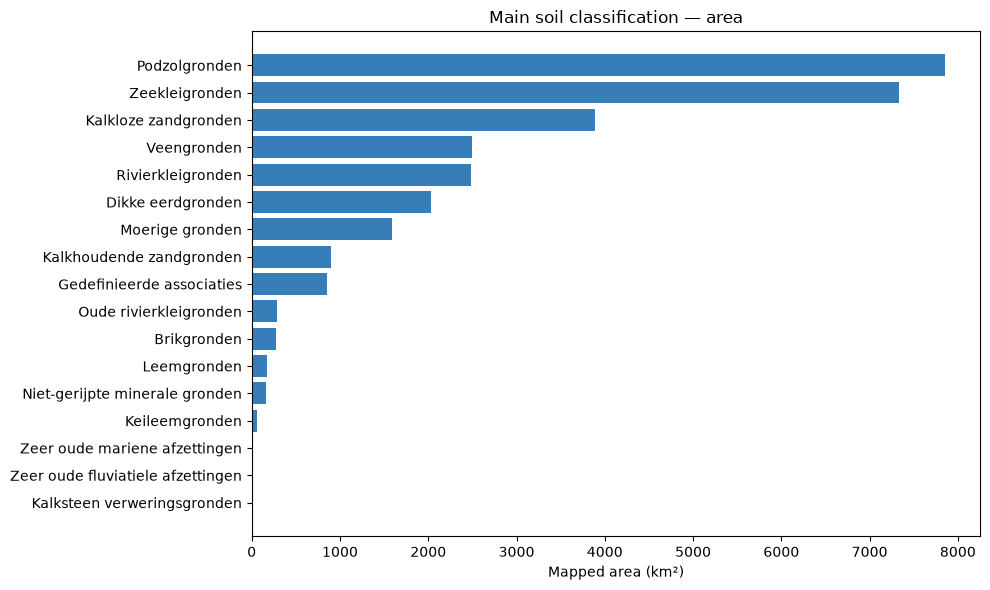

Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_eda\fig_soil_mainclass_counts.png


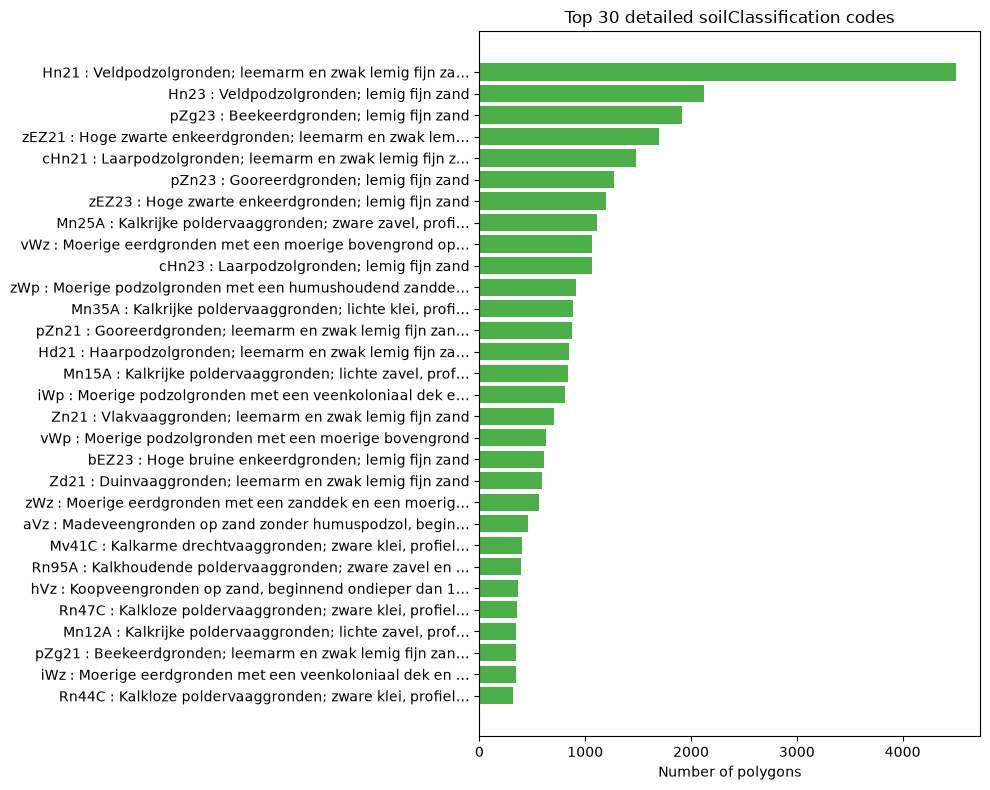

Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_eda\fig_soil_detailed_top_codes.png


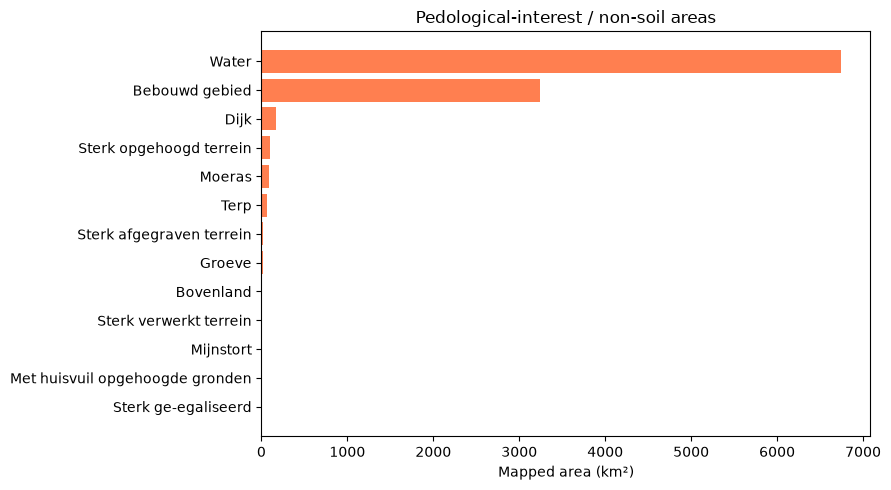

Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_eda\fig_soil_interest_counts.png


In [13]:
main_counts = (
    soil["main_soil_classification"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="n_polygons")
)
main_area = (
    soil.groupby("main_soil_classification", dropna=False)["area_m2"]
    .sum()
    .div(1e6)
    .rename("area_km2")
    .reset_index()
    .rename(columns={"main_soil_classification": "class"})
)
main_stats = main_counts.merge(main_area, on="class", how="left")
main_stats["kind"] = "main_soil_classification"

detail_counts = (
    soil["soil_classification"]
    .value_counts()
    .head(30)
    .rename_axis("class")
    .reset_index(name="n_polygons")
)
detail_counts["kind"] = "soil_classification_top30"

interest_counts = (
    interest["pedological_interest"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="n_polygons")
)
interest_area = (
    interest.groupby("pedological_interest", dropna=False)["area_m2"]
    .sum()
    .div(1e6)
    .rename("area_km2")
    .reset_index()
    .rename(columns={"pedological_interest": "class"})
)
interest_stats = interest_counts.merge(interest_area, on="class", how="left")
interest_stats["kind"] = "pedological_interest"

class_counts = pd.concat(
    [main_stats, detail_counts, interest_stats], ignore_index=True, sort=False
)
class_counts.to_csv(SOIL_FIG_DIR / "soil_class_counts.csv", index=False)
display(main_stats)
print(f"Saved {SOIL_FIG_DIR / 'soil_class_counts.csv'}")

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = main_stats.sort_values("area_km2", ascending=True)
ax.barh(plot_df["class"].astype(str), plot_df["area_km2"], color="#377eb8")
ax.set_xlabel("Mapped area (km²)")
ax.set_title("Main soil classification — area")
fig.tight_layout()
fig.savefig(SOIL_FIG_DIR / "fig_soil_mainclass_counts.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"Saved {SOIL_FIG_DIR / 'fig_soil_mainclass_counts.png'}")

fig, ax = plt.subplots(figsize=(10, 8))
top_detail = detail_counts.sort_values("n_polygons", ascending=True)
labels = [
    (c[:55] + "…") if isinstance(c, str) and len(c) > 55 else c
    for c in top_detail["class"]
]
ax.barh(labels, top_detail["n_polygons"], color="#4daf4a")
ax.set_xlabel("Number of polygons")
ax.set_title("Top 30 detailed soilClassification codes")
fig.tight_layout()
fig.savefig(SOIL_FIG_DIR / "fig_soil_detailed_top_codes.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"Saved {SOIL_FIG_DIR / 'fig_soil_detailed_top_codes.png'}")

fig, ax = plt.subplots(figsize=(9, 5))
int_plot = interest_stats.sort_values("area_km2", ascending=True)
ax.barh(int_plot["class"].astype(str), int_plot["area_km2"], color="coral")
ax.set_xlabel("Mapped area (km²)")
ax.set_title("Pedological-interest / non-soil areas")
fig.tight_layout()
fig.savefig(SOIL_FIG_DIR / "fig_soil_interest_counts.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"Saved {SOIL_FIG_DIR / 'fig_soil_interest_counts.png'}")


## 5. Spatial EDA — native choropleths

Maps use EPSG:28992. NUTS-3 boundaries are overlaid faintly for orientation.

NUTS-3 regions: 40


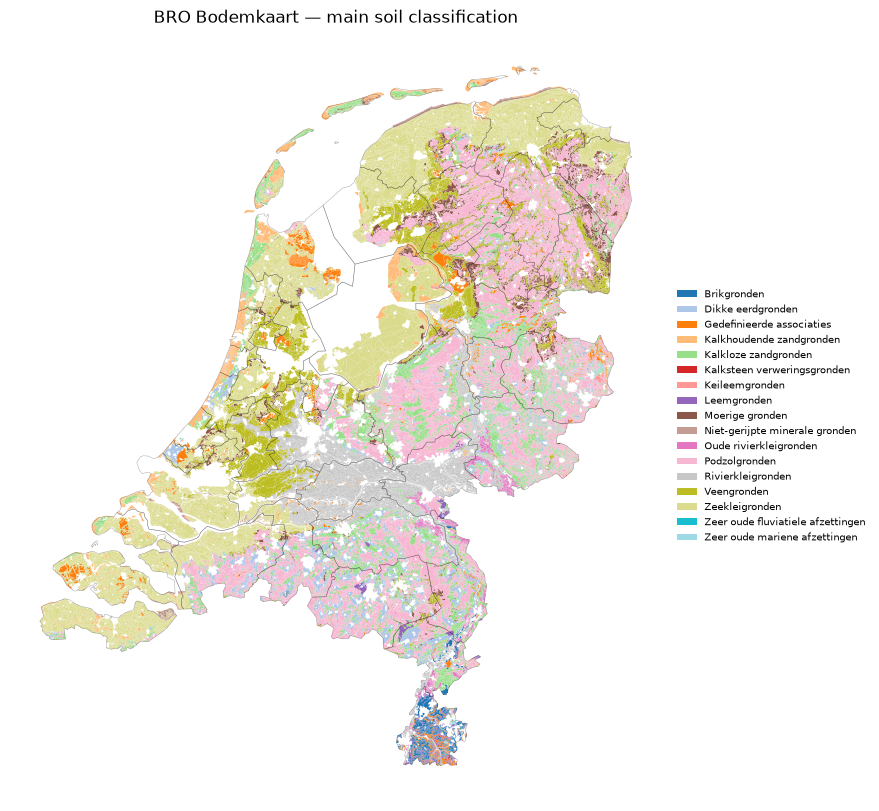

Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_eda\fig_soil_choropleth_mainclass.png


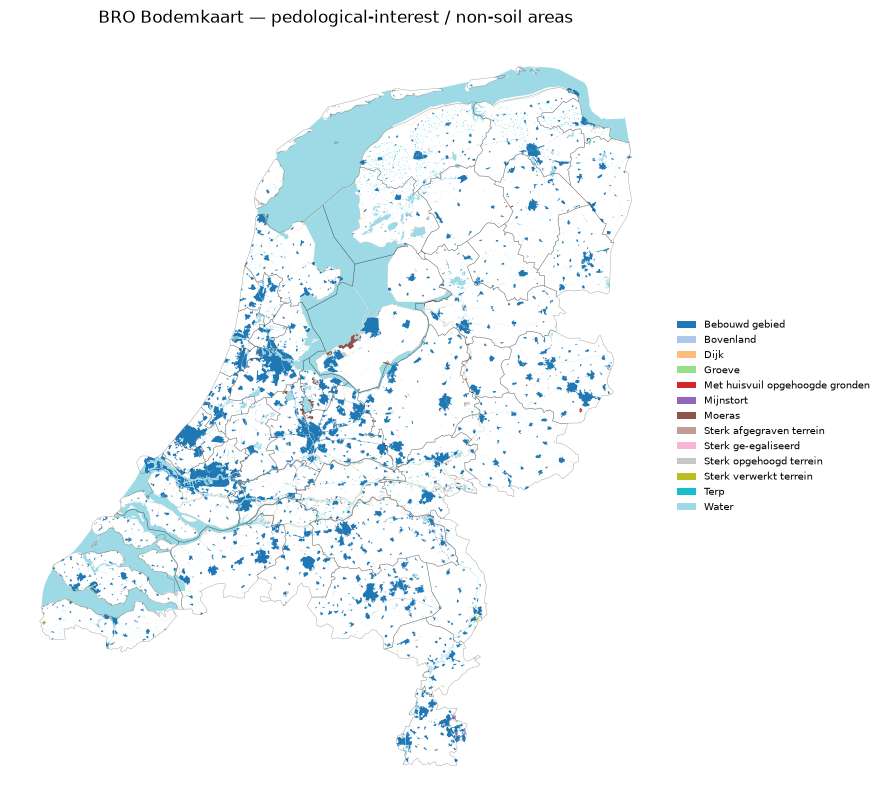

Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_eda\fig_soil_choropleth_interest.png


In [14]:
nuts_all = gpd.read_file(NUTS_GEOJSON)
nuts3 = nuts_all[nuts_all["LEVL_CODE"] == 3].to_crs(gdf.crs).copy()
print(f"NUTS-3 regions: {len(nuts3)}")

main_classes = sorted(soil["main_soil_classification"].dropna().unique())
cmap = plt.get_cmap("tab20", max(len(main_classes), 1))
color_map = {cls: cmap(i) for i, cls in enumerate(main_classes)}


def plot_categorical_map(
    frame: gpd.GeoDataFrame,
    column: str,
    title: str,
    save_name: str,
    colors: dict | None = None,
    figsize=(9, 10),
):
    fig, ax = plt.subplots(figsize=figsize)
    classes = sorted(frame[column].dropna().unique())
    if colors is None:
        local_cmap = plt.get_cmap("tab20", max(len(classes), 1))
        colors = {c: local_cmap(i) for i, c in enumerate(classes)}
    for cls in classes:
        subset = frame[frame[column] == cls]
        if len(subset):
            subset.plot(ax=ax, color=colors[cls], linewidth=0.05, edgecolor="none")
    nuts3.boundary.plot(ax=ax, color="black", linewidth=0.35, alpha=0.35)
    ax.set_title(title)
    ax.set_axis_off()
    handles = [Patch(facecolor=colors[c], edgecolor="none", label=c) for c in classes]
    ax.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        fontsize=7,
        frameon=False,
    )
    fig.savefig(SOIL_FIG_DIR / save_name, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved {SOIL_FIG_DIR / save_name}")


plot_categorical_map(
    soil,
    "main_soil_classification",
    "BRO Bodemkaart — main soil classification",
    "fig_soil_choropleth_mainclass.png",
    colors=color_map,
)

plot_categorical_map(
    interest,
    "pedological_interest",
    "BRO Bodemkaart — pedological-interest / non-soil areas",
    "fig_soil_choropleth_interest.png",
)


## 6. NUTS-3 aggregation — area-weighted main-class fractions

Intersect soil polygons with NUTS-3 regions and compute area shares of each `main_soil_classification`. Non-soil pedological-interest polygons are excluded here (flag separately if used as predictors).

In [15]:
soil_for_join = soil[["main_soil_classification", "geometry"]].copy()
nuts_for_join = nuts3[["NUTS_ID", "NAME_LATN", "geometry"]].copy()

print("Computing intersection overlay (may take ~20–30 s)…")
t0 = time.time()
inter = gpd.overlay(soil_for_join, nuts_for_join, how="intersection", keep_geom_type=False)
inter["inter_area_m2"] = inter.geometry.area
print(f"Overlay: {len(inter):,} pieces in {time.time() - t0:.1f}s")

area_by = (
    inter.groupby(["NUTS_ID", "NAME_LATN", "main_soil_classification"], dropna=False)[
        "inter_area_m2"
    ]
    .sum()
    .reset_index()
)
tot = area_by.groupby("NUTS_ID")["inter_area_m2"].transform("sum")
area_by["fraction"] = area_by["inter_area_m2"] / tot
area_by["area_km2"] = area_by["inter_area_m2"] / 1e6

frac_wide = area_by.pivot_table(
    index=["NUTS_ID", "NAME_LATN"],
    columns="main_soil_classification",
    values="fraction",
    fill_value=0.0,
).reset_index()
frac_wide.columns.name = None

dominant = (
    area_by.sort_values("fraction", ascending=False)
    .groupby(["NUTS_ID", "NAME_LATN"], as_index=False)
    .first()
    .rename(
        columns={
            "main_soil_classification": "dominant_main_class",
            "fraction": "dominant_fraction",
        }
    )[["NUTS_ID", "NAME_LATN", "dominant_main_class", "dominant_fraction"]]
)

frac_out = frac_wide.merge(dominant, on=["NUTS_ID", "NAME_LATN"], how="left")
frac_path = OUT_DIR / "soil_nuts3_mainclass_fractions.csv"
frac_out.to_csv(frac_path, index=False)
frac_out.to_parquet(
    OUT_DIR / "soil_nuts3_mainclass_fractions.parquet",
    index=False,
)
display(frac_out.head())
print(f"Saved {frac_path}")
print(f"Saved {OUT_DIR / 'soil_nuts3_mainclass_fractions.parquet'}")


Computing intersection overlay (may take ~20–30 s)…
Overlay: 50,471 pieces in 8.1s


,NUTS_ID,NAME_LATN,Brikgronden,Dikke eerdgronden,Gedefinieerde associaties,Kalkhoudende zandgronden,Kalkloze zandgronden,Kalksteen verweringsgronden,Keileemgronden,Leemgronden,...,Niet-gerijpte minerale gronden,Oude rivierkleigronden,Podzolgronden,Rivierkleigronden,Veengronden,Zeekleigronden,Zeer oude fluviatiele afzettingen,Zeer oude mariene afzettingen,dominant_main_class,dominant_fraction
0,NL111,Oost-Groningen,0.0,0.000990,0.007776,0.000000,0.111930,0.0,0.002513,0.0,...,0.005279,0.0,0.393359,0.0,0.036937,0.264535,0.0,0.0,Podzolgronden,0.393359
1,NL112,Delfzijl en omgeving,0.0,0.000000,0.000000,0.000000,0.001288,0.0,0.000000,0.0,...,0.002992,0.0,0.004072,0.0,0.035762,0.947138,0.0,0.0,Zeekleigronden,0.947138
2,NL113,Overig Groningen,0.0,0.013892,0.008410,0.037348,0.015761,0.0,0.001286,0.0,...,0.006038,0.0,0.165409,0.0,0.085403,0.574619,0.0,0.0,Zeekleigronden,0.574619
3,NL124,Noord-Friesland,0.0,0.013327,0.011747,0.058248,0.083456,0.0,0.000157,0.0,...,0.012667,0.0,0.093694,0.0,0.055388,0.628286,0.0,0.0,Zeekleigronden,0.628286
4,NL125,Zuidwest-Friesland,0.0,0.008086,0.009500,0.016689,0.002378,0.0,0.000912,0.0,...,0.000000,0.0,0.128528,0.0,0.316948,0.425513,0.0,0.0,Zeekleigronden,0.425513


Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_nuts3_mainclass_fractions.csv
Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_nuts3_mainclass_fractions.parquet


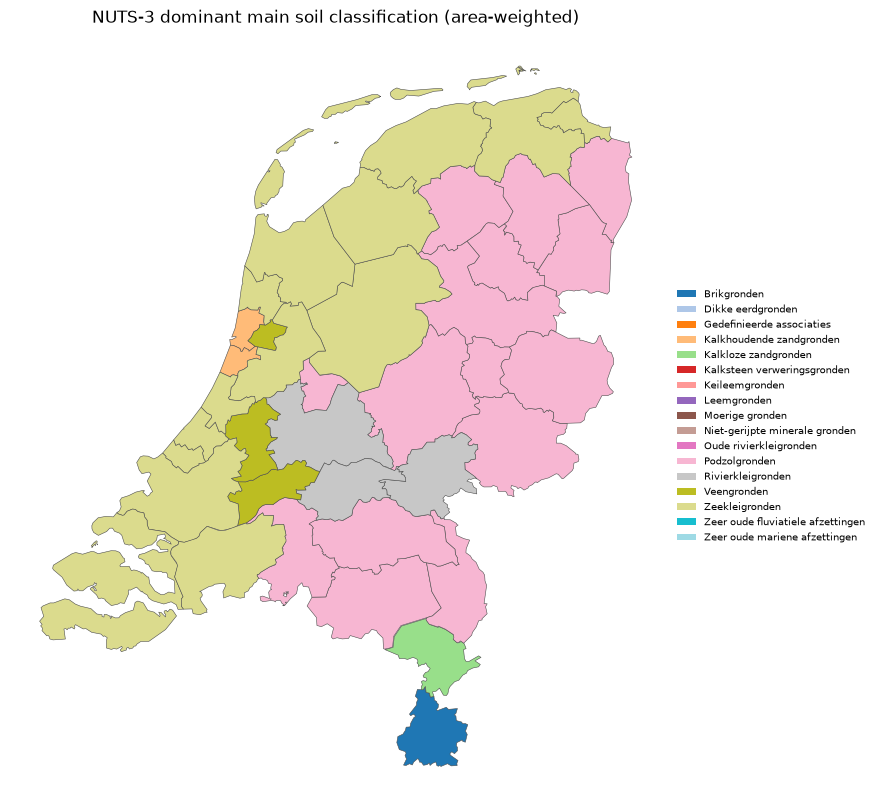

Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_eda\fig_soil_nuts3_dominant_class.png


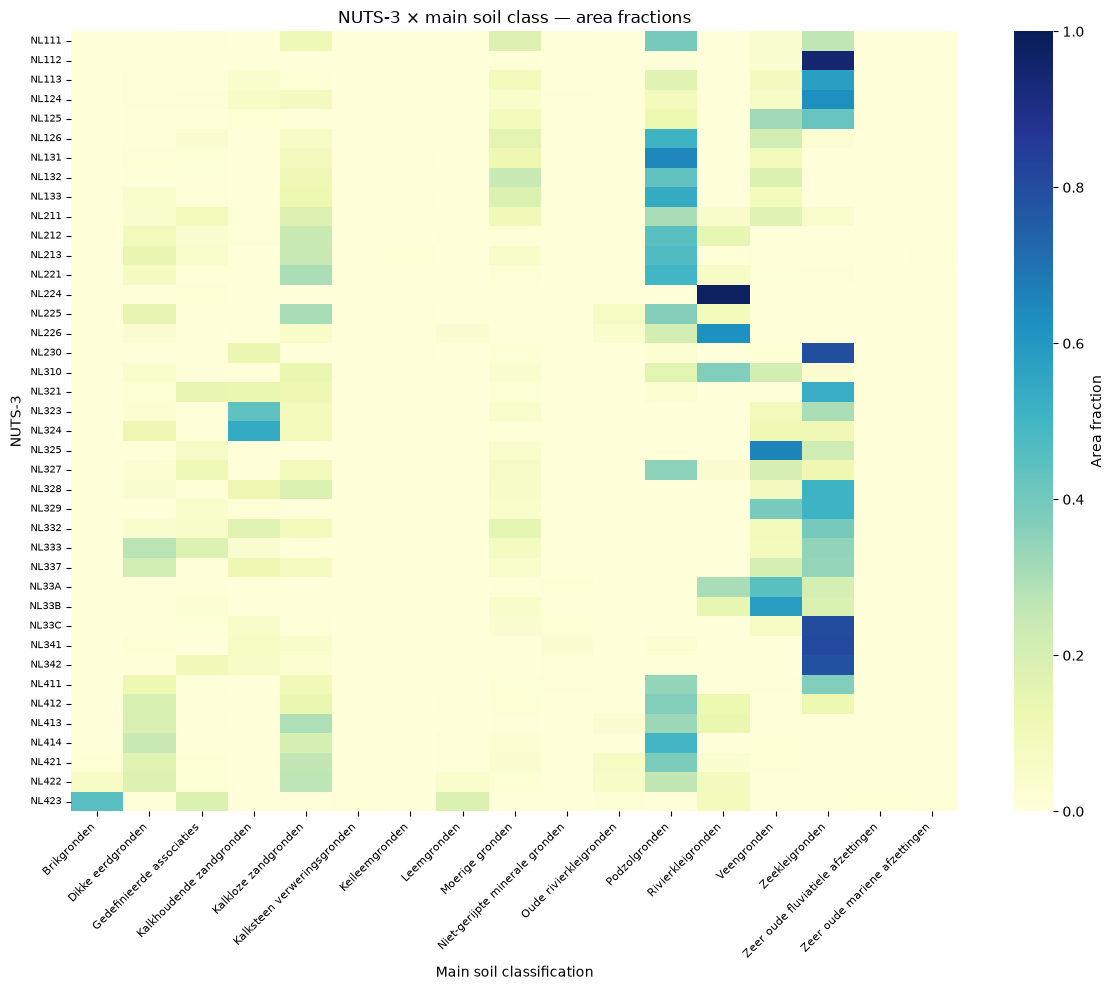

Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_eda\fig_soil_nuts3_class_fractions.png


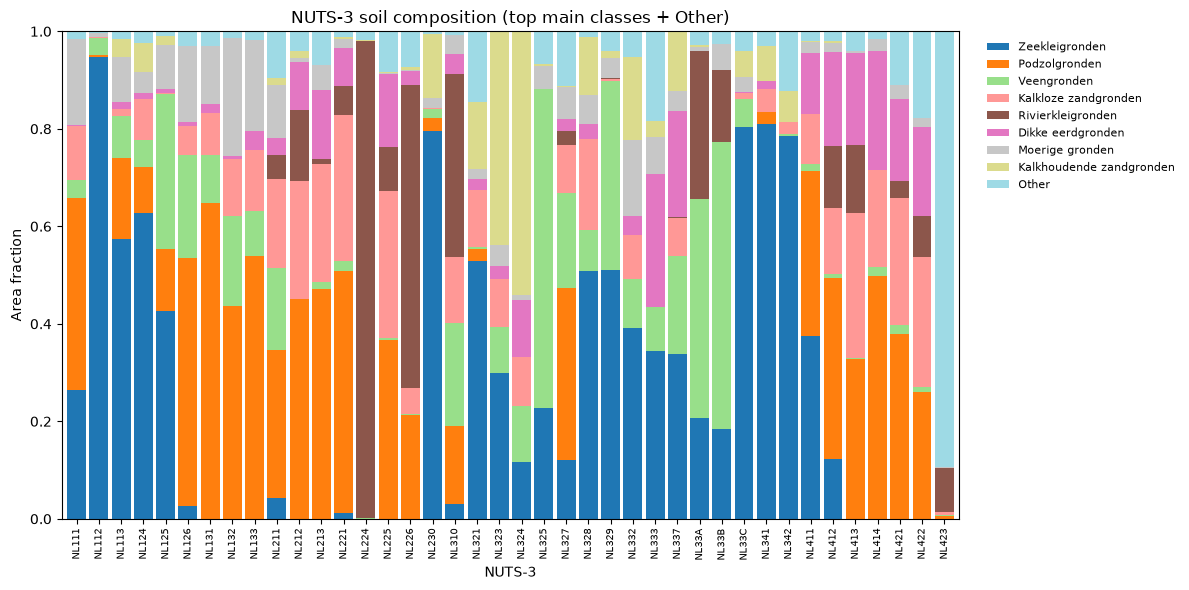

Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_eda\fig_soil_nuts3_stacked_fractions.png


In [16]:
nuts_dom = nuts3.merge(dominant, on=["NUTS_ID", "NAME_LATN"], how="left")

fig, ax = plt.subplots(figsize=(9, 10))
for cls in main_classes:
    subset = nuts_dom[nuts_dom["dominant_main_class"] == cls]
    if len(subset):
        subset.plot(ax=ax, color=color_map[cls], edgecolor="0.3", linewidth=0.4)
missing_dom = nuts_dom[nuts_dom["dominant_main_class"].isna()]
if len(missing_dom):
    missing_dom.plot(ax=ax, color="#ebeff5", edgecolor="0.3", linewidth=0.4)
ax.set_title("NUTS-3 dominant main soil classification (area-weighted)")
ax.set_axis_off()
handles = [Patch(facecolor=color_map[c], edgecolor="none", label=c) for c in main_classes]
ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=7,
    frameon=False,
)
fig.savefig(SOIL_FIG_DIR / "fig_soil_nuts3_dominant_class.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"Saved {SOIL_FIG_DIR / 'fig_soil_nuts3_dominant_class.png'}")

heat = frac_wide.set_index("NUTS_ID").drop(columns=["NAME_LATN"], errors="ignore")
class_cols = [c for c in main_classes if c in heat.columns]
heat = heat[class_cols]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    heat,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    ax=ax,
    cbar_kws={"label": "Area fraction"},
)
ax.set_title("NUTS-3 × main soil class — area fractions")
ax.set_xlabel("Main soil classification")
ax.set_ylabel("NUTS-3")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=7)
fig.tight_layout()
fig.savefig(SOIL_FIG_DIR / "fig_soil_nuts3_class_fractions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"Saved {SOIL_FIG_DIR / 'fig_soil_nuts3_class_fractions.png'}")

mean_share = heat.mean().sort_values(ascending=False)
top_k = list(mean_share.head(8).index)
stack = heat[top_k].copy()
stack["Other"] = (1.0 - stack.sum(axis=1)).clip(lower=0)

fig, ax = plt.subplots(figsize=(12, 6))
stack.plot(kind="bar", stacked=True, ax=ax, width=0.85, colormap="tab20")
ax.set_ylabel("Area fraction")
ax.set_xlabel("NUTS-3")
ax.set_title("NUTS-3 soil composition (top main classes + Other)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
plt.xticks(rotation=90, fontsize=7)
fig.tight_layout()
fig.savefig(SOIL_FIG_DIR / "fig_soil_nuts3_stacked_fractions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"Saved {SOIL_FIG_DIR / 'fig_soil_nuts3_stacked_fractions.png'}")


In [17]:
spatial_summary = {
    "n_soil_polygons": len(soil),
    "n_interest_polygons": len(interest),
    "soil_area_km2": round(soil["area_m2"].sum() / 1e6, 1),
    "interest_area_km2": round(interest["area_m2"].sum() / 1e6, 1),
    "n_main_classes": int(soil["main_soil_classification"].nunique()),
    "n_detailed_classes": int(soil["soil_classification"].nunique()),
    "n_nuts3_with_soil": int(frac_out["NUTS_ID"].nunique()),
    "bbox_xmin": round(float(gdf.total_bounds[0]), 1),
    "bbox_ymin": round(float(gdf.total_bounds[1]), 1),
    "bbox_xmax": round(float(gdf.total_bounds[2]), 1),
    "bbox_ymax": round(float(gdf.total_bounds[3]), 1),
}
pd.Series(spatial_summary).to_frame("value").to_csv(OUT_DIR / "soil_spatial_summary.csv")
display(pd.Series(spatial_summary).to_frame("value"))
print(f"Saved {OUT_DIR / 'soil_spatial_summary.csv'}")

q75 = dominant["dominant_fraction"].quantile(0.75)
q25 = dominant["dominant_fraction"].quantile(0.25)
top_bottom = dominant.sort_values("dominant_fraction", ascending=False).copy()
top_bottom["rank_group"] = np.where(
    top_bottom["dominant_fraction"] >= q75,
    "high_dominance",
    np.where(top_bottom["dominant_fraction"] <= q25, "low_dominance", "mid"),
)
top_bottom.to_csv(OUT_DIR / "soil_nuts3_dominance.csv", index=False)
display(top_bottom.head(10))
print(f"Saved {OUT_DIR / 'soil_nuts3_dominance.csv'}")


,value
n_soil_polygons,48025.0
n_interest_polygons,6192.0
soil_area_km2,30426.2
interest_area_km2,10478.7
n_main_classes,17.0
n_detailed_classes,305.0
n_nuts3_with_soil,40.0
bbox_xmin,13579.0
bbox_ymin,306870.2
bbox_xmax,278042.0


Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_spatial_summary.csv


,NUTS_ID,NAME_LATN,dominant_main_class,dominant_fraction,rank_group
13,NL224,Zuidwest-Gelderland,Rivierkleigronden,0.976995,high_dominance
1,NL112,Delfzijl en omgeving,Zeekleigronden,0.947138,high_dominance
31,NL341,Zeeuwsch-Vlaanderen,Zeekleigronden,0.809384,high_dominance
30,NL33C,Groot-Rijnmond,Zeekleigronden,0.804552,high_dominance
16,NL230,Flevoland,Zeekleigronden,0.795618,high_dominance
32,NL342,Overig Zeeland,Zeekleigronden,0.785292,high_dominance
21,NL325,Zaanstreek,Veengronden,0.655933,high_dominance
6,NL131,Noord-Drenthe,Podzolgronden,0.647832,high_dominance
3,NL124,Noord-Friesland,Zeekleigronden,0.628286,high_dominance
15,NL226,Arnhem/Nijmegen,Rivierkleigronden,0.622388,high_dominance


Saved C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\soil_nuts3_dominance.csv


## 7. Modelling notes

Soil composition is still listed as **skipped** in `Data_preparation_prediction.ipynb` (that notebook currently uses Copernicus **soil moisture anomaly**, not BRO composition).

### Recommended static features

1. **Area fractions** of `main_soil_classification` per NUTS-3 — already exported as `soil_nuts3_mainclass_fractions.csv` / `.parquet` (one row per region, columns = class shares + dominant class).
2. Optionally collapse rare classes into an `Other` bucket, or keep only the top-k national classes.
3. Optionally add a **non-soil share** (water / built-up / dikes) from pedological-interest polygons via the same overlay.

### Caveats

- **CRS:** BRO is EPSG:28992; NUTS geojson is EPSG:4326 — always reproject before overlay.
- **Categorical vector data:** use area-weighted fractions (or dominant class), not raster zonal means.
- **Exclude or flag** `AreaOfPedologicalInterest` when deriving agricultural soil predictors.
- **Profiles are sparse:** quantitative OM/texture live mainly on linked `NormalSoilProfile` objects, not on every polygon; this EDA focuses on map classifications.
- **Static in time:** V2025-01 is a map snapshot — suitable as time-invariant regional context for the 2018–2025 panel.

### Relation to `soil_tif_utils.py`

That helper is for soil-**moisture** GeoTIFFs only. Do not reuse it for this BRO GML file.

## 8. Output checklist

Hand-in requires curated figures under `results/figures/statics/` plus modelling tables (elevation / soil parquets). Full EDA galleries under `soil_eda/` and `images_for_elevation_eda/` are optional rebuild artifacts and are not shipped.


In [18]:
import shutil

# Promote curated figures into the hand-in path (full EDA galleries stay optional under soil_eda / images_for_elevation_eda)
CURATED = [
    (FIG_DIR / "fig_elevation_nuts3_choropleth.png", STATIC_FIG_DIR / "fig_elevation_nuts3_choropleth.png"),
    (SOIL_FIG_DIR / "fig_soil_choropleth_mainclass.png", STATIC_FIG_DIR / "fig_soil_choropleth_mainclass.png"),
    (SOIL_FIG_DIR / "fig_soil_nuts3_dominant_class.png", STATIC_FIG_DIR / "fig_soil_nuts3_dominant_class.png"),
    (SOIL_FIG_DIR / "fig_soil_nuts3_stacked_fractions.png", STATIC_FIG_DIR / "fig_soil_nuts3_stacked_fractions.png"),
]
for src, dst in CURATED:
    if src.exists():
        shutil.copy2(src, dst)
        print(f"Curated -> {dst.relative_to(PACKAGE_ROOT)}")
    elif dst.exists():
        print(f"Curated (already present) {dst.relative_to(PACKAGE_ROOT)}")
    else:
        print(f"MISSING curated source: {src}")

expected_outputs = [
    # Curated hand-in figures
    ("fig_elevation_nuts3_choropleth.png", STATIC_FIG_DIR),
    ("fig_soil_choropleth_mainclass.png", STATIC_FIG_DIR),
    ("fig_soil_nuts3_dominant_class.png", STATIC_FIG_DIR),
    ("fig_soil_nuts3_stacked_fractions.png", STATIC_FIG_DIR),
    # Modelling tables at processed root
    ("soil_nuts3_mainclass_fractions.parquet", OUT_DIR),
    ("soil_nuts3_mainclass_fractions.csv", OUT_DIR),
    ("soil_nuts3_dominance.csv", OUT_DIR),
    ("static_elevation_nuts3.parquet", OUT_DIR),
    ("static_elevation_nuts3.csv", OUT_DIR),
    ("static_soil_composition_nuts3.parquet", OUT_DIR),
]

print(f"Processed: {OUT_DIR}")
print(f"Curated figures: {STATIC_FIG_DIR}")
for name, folder in expected_outputs:
    path = folder / name
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}] {path.relative_to(PACKAGE_ROOT)}")

print(f"  [optional] BRO GPKG cache regenerable at {GPKG_CACHE.name} — not required for hand-in")


Curated -> results\figures\statics\fig_elevation_nuts3_choropleth.png
Curated -> results\figures\statics\fig_soil_choropleth_mainclass.png
Curated -> results\figures\statics\fig_soil_nuts3_dominant_class.png
Curated -> results\figures\statics\fig_soil_nuts3_stacked_fractions.png
Processed: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed
Curated figures: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\results\figures\statics
  [OK] results\figures\statics\fig_elevation_nuts3_choropleth.png
  [OK] results\figures\statics\fig_soil_choropleth_mainclass.png
  [OK] results\figures\statics\fig_soil_nuts3_dominant_class.png
  [OK] results\figures\statics\fig_soil_nuts3_stacked_fractions.png
  [OK] data\processed\soil_nuts3_mainclass_fractions.parquet
  [OK] data\proc

## Done

Expected outputs in `data/processed/`:
- `static_elevation_nuts3.parquet`
- `soil_nuts3_mainclass_fractions.parquet` (notebook 02 renames to `static_soil_composition_nuts3.parquet`)
